## Stage 2 Unlearning - All 4 Methods

Paper: FIUBench (ICLR 2025)  
Goal: Train GA, GD, KL, PO unlearning on Stage 1 checkpoint using exact hyperparameters from Table 7.

| Method | forget_loss | lr   | batch | accum | epochs | split   |
|--------|-------------|------|-------|-------|--------|---------|
| GA     | ga          | 2e-5 | 8     | 16    | 8      | forget5 |
| GD     | gd          | 2e-5 | 8     | 16    | 8      | forget5 |
| KL     | kl          | 1e-4 | 8     | 16    | 8      | forget5 |
| PO     | idk         | 3e-4 | 8     | 16    | 8      | forget5 |

Run cells sequentially. Each method saves its checkpoint to Drive before the next begins.


## Repo + Drive + GPU




In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import subprocess

result = subprocess.run(
    "git clone https://YOUR_TOKEN@github.com/akashyall34/FIUBench_Reproducing.git /content/FIUBench_Reproducing",
    shell=True, capture_output=True, text=True
)
print(result.stdout or result.stderr)

Cloning into '/content/FIUBench_Reproducing'...



In [14]:
import subprocess
from pathlib import Path

PROJECT_ROOT = '/content/FIUBench_Reproducing'

print(f"Pulling latest changes from GitHub...\n")

# Stash local changes first to avoid conflicts
print("Stashing local changes...")
result = subprocess.run(
    "git stash",
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    shell=True
)
if result.returncode == 0 and result.stdout.strip():
    print(result.stdout)
else:
    print("(no local changes to stash)")

# Now pull
result = subprocess.run(
    "git pull",
    cwd=PROJECT_ROOT,
    capture_output=True,
    text=True,
    shell=True
)

if result.returncode == 0:
    print("✅ Repository updated")
    print(result.stdout)
else:
    print("❌ Pull failed")
    print(result.stderr)

Pulling latest changes from GitHub...

Stashing local changes...
No local changes to save

✅ Repository updated
Updating 8925551..0fd10a8
Fast-forward
 scripts/plot_figure2.py | 115 ++++++++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 115 insertions(+)
 create mode 100644 scripts/plot_figure2.py



## Install dependencies

In [4]:
import subprocess, sys

deps = [
    "torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1",
    "transformers==4.48.0",
    "xtuner==0.2.0",
    "accelerate==0.34.2",
    "datasets==2.21.0",
    "peft==0.13.2",
    "pillow",
    "scikit-learn",
    "rouge-score",
    "open-clip-torch",
    "python-dotenv",
    "openai",
    "hydra-core",
    "scipy",
    "deepspeed",
]

for dep in deps:
    subprocess.run(f"{sys.executable} -m pip install -q {dep}", shell=True)

import transformers
import torch
print(f"✅ torch={torch.__version__}  transformers={transformers.__version__}")

✅ torch=2.4.1+cu121  transformers=4.48.0


## Patches + copy Stage 1 from Drive

In [5]:
import os, re
from pathlib import Path

STAGE1_LOCAL = '/content/stage1_final'
STAGE1_DRIVE = '/content/drive/MyDrive/fiubench_checkpoints/stage1_checkpoints'
FIUBENCH_DIR = '/content/FIUBench_Reproducing/FIUBench'

os.environ['WANDB_MODE']     = 'disabled'
os.environ['HYDRA_FULL_ERROR'] = '1'

# ── 1. Copy Stage 1 from Drive ────────────────────────────────────────────────
if not Path(STAGE1_LOCAL).exists() or not list(Path(STAGE1_LOCAL).glob('*.safetensors')):
    print("Copying Stage 1 from Drive...")
    Path(STAGE1_LOCAL).mkdir(parents=True, exist_ok=True)
    ret = os.system(f'rsync -ah --progress {STAGE1_DRIVE}/ {STAGE1_LOCAL}/')
    assert ret == 0, "rsync failed"
safetensors = list(Path(STAGE1_LOCAL).glob('*.safetensors'))
assert safetensors, f"No safetensors in {STAGE1_LOCAL}"
print(f"✅ Stage 1 ready: {[f.name for f in safetensors]}")

# ── 2. Patch forget.py ────────────────────────────────────────────────────────
fg_py = Path(FIUBENCH_DIR) / 'forget.py'
src = fg_py.read_text()
patched = src
patched = patched.replace('attn_implementation="flash_attention_2"', 'attn_implementation="sdpa"')
patched = patched.replace('torch_dtype=torch.float16', 'torch_dtype=torch.bfloat16')
patched = patched.replace('.to(torch.float16)', '')
patched = patched.replace(
    'accelerator = Accelerator(\n        gradient_accumulation_steps=cfg.gradient_accumulation_steps,\n        **accelerator_log_kwargs)',
    'accelerator = Accelerator(\n        gradient_accumulation_steps=cfg.gradient_accumulation_steps,\n        mixed_precision="bf16",\n        **accelerator_log_kwargs)'
)
patched = patched.replace(
    'accelerator.end_training()\n    output_dir = cfg.save_dir\n    accelerator.wait_for_everyone()',
    'output_dir = cfg.save_dir\n    accelerator.wait_for_everyone()\n    accelerator.end_training()'
)
if patched != src:
    fg_py.write_text(patched)
    print("✅ Patched forget.py")
else:
    print("✅ forget.py already patched")

assert 'torch_dtype=torch.bfloat16' in fg_py.read_text(), "bfloat16 patch missing"
assert 'mixed_precision="bf16"'      in fg_py.read_text(), "mixed_precision patch missing"

# ── 3. Patch modeling_llava.py ────────────────────────────────────────────────
import glob
llava_candidates = glob.glob(
    '/usr/local/lib/python*/dist-packages/transformers/models/llava/modeling_llava.py'
)
if llava_candidates:
    llava_path = llava_candidates[0]
    llava_src  = Path(llava_path).read_text()
    llava_patched = re.sub(
        r'n_image_tokens != n_image_features',
        'False',
        llava_src
    )
    if llava_patched != llava_src:
        Path(llava_path).write_text(llava_patched)
        print(f"✅ Patched modeling_llava.py")
    else:
        print("✅ modeling_llava.py already patched")
else:
    print("⚠️  modeling_llava.py not found — may not be needed for this transformers version")

print("\n✅ All patches applied. Ready for Stage 2.")


Copying Stage 1 from Drive...
✅ Stage 1 ready: ['model-00001-of-00002.safetensors', 'model-00002-of-00002.safetensors']
✅ forget.py already patched
✅ Patched modeling_llava.py

✅ All patches applied. Ready for Stage 2.


## Stage 2: Gradient Ascent (GA)

In [27]:
import os, subprocess, time
from pathlib import Path

STAGE1_LOCAL = '/content/stage1_final'
FIUBENCH_DIR = '/content/FIUBench_Reproducing/FIUBench'
METHOD       = 'ga'
LR           = '2e-5'
STAGE2_LOCAL = f'/content/stage2_{METHOD}'
STAGE2_DRIVE = f'/content/drive/MyDrive/fiubench_checkpoints/stage2_forget5/{METHOD}'

Path(STAGE2_LOCAL).mkdir(parents=True, exist_ok=True)

cmd = (
    f"cd {FIUBENCH_DIR} && "
    f"torchrun --nproc_per_node=1 --master_port=29510 forget.py "
    f"--config-name forget_lora "
    f"model_path={STAGE1_LOCAL} "
    f"save_dir={STAGE2_LOCAL} "
    f"split=forget5 "
    f"forget_loss={METHOD} "
    f"lr={LR} "
    f"batch_size=8 "
    f"num_epochs=8 "
    f"seed=233 "
    f"overwrite_dir=true "
    f"2>&1 | tee /tmp/forget_{METHOD}_log.txt"
)

print(f"Starting Stage 2 [{METHOD.upper()}]  lr={LR}  batch=8  accum=16  epochs=8  split=forget5")
print("=" * 70)
t0 = time.time()
proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()
ret = proc.returncode

elapsed = time.time() - t0
h, m, s = int(elapsed//3600), int((elapsed%3600)//60), int(elapsed%60)
print(f"\nExit: {ret}  |  Time: {h}h {m}m {s}s")

if ret == 0:
    Path(STAGE2_DRIVE).mkdir(parents=True, exist_ok=True)
    os.system(f"rsync -ah --progress {STAGE2_LOCAL}/ {STAGE2_DRIVE}/")
    os.system(f"cp /tmp/forget_{METHOD}_log.txt {STAGE2_DRIVE}/training_log.txt")
    print(f"✅ GA checkpoints saved to {STAGE2_DRIVE}")
    print(f"✅ GA training log saved to {STAGE2_DRIVE}/training_log.txt")
else:
    print(f"❌ GA failed (exit {ret}). Check /tmp/forget_{METHOD}_log.txt")

Starting Stage 2 [GA]  lr=2e-5  batch=8  accum=16  epochs=8  split=forget5
2026-04-19 19:26:56.393409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776626816.415148   10558 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776626816.421837   10558 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776626816.438565   10558 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776626816.438597   10558 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:

## Stage 2: Gradient Difference (GD)

In [28]:
import os, subprocess, time
from pathlib import Path

STAGE1_LOCAL = '/content/stage1_final'
FIUBENCH_DIR = '/content/FIUBench_Reproducing/FIUBench'
METHOD       = 'gd'
LR           = '2e-5'
STAGE2_LOCAL = f'/content/stage2_{METHOD}'
STAGE2_DRIVE = f'/content/drive/MyDrive/fiubench_checkpoints/stage2_forget5/{METHOD}'

Path(STAGE2_LOCAL).mkdir(parents=True, exist_ok=True)

cmd = (
    f"cd {FIUBENCH_DIR} && "
    f"torchrun --nproc_per_node=1 --master_port=29511 forget.py "
    f"--config-name forget_lora "
    f"model_path={STAGE1_LOCAL} "
    f"save_dir={STAGE2_LOCAL} "
    f"split=forget5 "
    f"forget_loss={METHOD} "
    f"lr={LR} "
    f"batch_size=8 "
    f"num_epochs=8 "
    f"seed=233 "
    f"overwrite_dir=true "
    f"2>&1 | tee /tmp/forget_{METHOD}_log.txt"
)

print(f"Starting Stage 2 [{METHOD.upper()}]  lr={LR}  batch=8  accum=16  epochs=8  split=forget5")
print("=" * 70)
t0 = time.time()
proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()
ret = proc.returncode

elapsed = time.time() - t0
h, m, s = int(elapsed//3600), int((elapsed%3600)//60), int(elapsed%60)
print(f"\nExit: {ret}  |  Time: {h}h {m}m {s}s")

if ret == 0:
    Path(STAGE2_DRIVE).mkdir(parents=True, exist_ok=True)
    os.system(f"rsync -ah --progress {STAGE2_LOCAL}/ {STAGE2_DRIVE}/")
    os.system(f"cp /tmp/forget_{METHOD}_log.txt {STAGE2_DRIVE}/training_log.txt")
    print(f"✅ GD checkpoints saved to {STAGE2_DRIVE}")
    print(f"✅ GD training log saved to {STAGE2_DRIVE}/training_log.txt")
else:
    print(f"❌ GD failed (exit {ret}). Check /tmp/forget_{METHOD}_log.txt")


Starting Stage 2 [GD]  lr=2e-5  batch=8  accum=16  epochs=8  split=forget5
2026-04-19 19:32:44.125881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776627164.147182   13016 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776627164.153670   13016 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776627164.170075   13016 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776627164.170101   13016 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:

## Stage 2: KL Minimization (KL)

In [32]:
import os, subprocess, time
from pathlib import Path

STAGE1_LOCAL = '/content/stage1_final'
FIUBENCH_DIR = '/content/FIUBench_Reproducing/FIUBench'
METHOD       = 'kl'
LR           = '1e-4'
STAGE2_LOCAL = f'/content/stage2_{METHOD}'
STAGE2_DRIVE = f'/content/drive/MyDrive/fiubench_checkpoints/stage2_forget5/{METHOD}'

Path(STAGE2_LOCAL).mkdir(parents=True, exist_ok=True)

cmd = (
    f"cd {FIUBENCH_DIR} && "
    f"torchrun --nproc_per_node=1 --master_port=29512 forget.py "
    f"--config-name forget_lora "
    f"model_path={STAGE1_LOCAL} "
    f"save_dir={STAGE2_LOCAL} "
    f"split=forget5 "
    f"forget_loss={METHOD} "
    f"lr={LR} "
    f"batch_size=8 "
    f"num_epochs=8 "
    f"seed=233 "
    f"overwrite_dir=true "
    f"2>&1 | tee /tmp/forget_{METHOD}_log.txt"
)

print(f"Starting Stage 2 [{METHOD.upper()}]  lr={LR}  batch=8  accum=16  epochs=8  split=forget5")
print("=" * 70)
t0 = time.time()
proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()
ret = proc.returncode

elapsed = time.time() - t0
h, m, s = int(elapsed//3600), int((elapsed%3600)//60), int(elapsed%60)
print(f"\nExit: {ret}  |  Time: {h}h {m}m {s}s")

if ret == 0:
    Path(STAGE2_DRIVE).mkdir(parents=True, exist_ok=True)
    os.system(f"rsync -ah --progress {STAGE2_LOCAL}/ {STAGE2_DRIVE}/")
    os.system(f"cp /tmp/forget_{METHOD}_log.txt {STAGE2_DRIVE}/training_log.txt")
    print(f"✅ KL checkpoints saved to {STAGE2_DRIVE}")
    print(f"✅ KL training log saved to {STAGE2_DRIVE}/training_log.txt")
else:
    print(f"❌ KL failed (exit {ret}). Check /tmp/forget_{METHOD}_log.txt")


Starting Stage 2 [KL]  lr=1e-4  batch=8  accum=16  epochs=8  split=forget5
2026-04-19 19:39:38.368088: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776627578.391650   15923 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776627578.398541   15923 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776627578.415941   15923 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776627578.415985   15923 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:

## Stage 2: Preference Optimization / IDK (PO)

In [33]:
import os, subprocess, time
from pathlib import Path

STAGE1_LOCAL = '/content/stage1_final'
FIUBENCH_DIR = '/content/FIUBench_Reproducing/FIUBench'
METHOD       = 'idk'
LABEL        = 'po'
LR           = '3e-4'
STAGE2_LOCAL = f'/content/stage2_{LABEL}'
STAGE2_DRIVE = f'/content/drive/MyDrive/fiubench_checkpoints/stage2_forget5/{LABEL}'

Path(STAGE2_LOCAL).mkdir(parents=True, exist_ok=True)

cmd = (
    f"cd {FIUBENCH_DIR} && "
    f"torchrun --nproc_per_node=1 --master_port=29513 forget.py "
    f"--config-name forget_lora "
    f"model_path={STAGE1_LOCAL} "
    f"save_dir={STAGE2_LOCAL} "
    f"split=forget5 "
    f"forget_loss={METHOD} "
    f"lr={LR} "
    f"batch_size=8 "
    f"num_epochs=8 "
    f"seed=233 "
    f"overwrite_dir=true "
    f"2>&1 | tee /tmp/forget_{LABEL}_log.txt"
)

print(f"Starting Stage 2 [PO/IDK]  lr={LR}  batch=8  accum=16  epochs=8  split=forget5")
print("=" * 70)
t0 = time.time()
proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()
ret = proc.returncode

elapsed = time.time() - t0
h, m, s = int(elapsed//3600), int((elapsed%3600)//60), int(elapsed%60)
print(f"\nExit: {ret}  |  Time: {h}h {m}m {s}s")

if ret == 0:
    Path(STAGE2_DRIVE).mkdir(parents=True, exist_ok=True)
    os.system(f"rsync -ah --progress {STAGE2_LOCAL}/ {STAGE2_DRIVE}/")
    os.system(f"cp /tmp/forget_{LABEL}_log.txt {STAGE2_DRIVE}/training_log.txt")
    print(f"✅ PO checkpoints saved to {STAGE2_DRIVE}")
    print(f"✅ PO training log saved to {STAGE2_DRIVE}/training_log.txt")
else:
    print(f"❌ PO failed (exit {ret}). Check /tmp/forget_{LABEL}_log.txt")


Starting Stage 2 [PO/IDK]  lr=3e-4  batch=8  accum=16  epochs=8  split=forget5
2026-04-19 19:45:57.330034: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776627957.353183   18515 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776627957.360590   18515 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776627957.377977   18515 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776627957.378021   18515 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00

## Retain model baseline

In [49]:
# The retain model is fine-tuned on S_R (excludes all forget sets).
# It is the ideal unlearning upper bound used for KS-Test in Day 5.
# Training: same as Stage 1 but with split=retain to exclude forget sets.

import os, subprocess, time
from pathlib import Path

PROJECT_ROOT   = '/content/FIUBench_Reproducing'
FIUBENCH_DIR   = f'{PROJECT_ROOT}/FIUBench'
RETAIN_LOCAL   = '/content/retain_model'
RETAIN_DRIVE   = '/content/drive/MyDrive/fiubench_checkpoints/retain_model'

Path(RETAIN_LOCAL).mkdir(parents=True, exist_ok=True)

# Fine-tune on retain identities using same Stage 1 hyperparameters
# lr=2e-5, batch=8, accum=16, epochs=10, full fine-tuning (no LoRA)
cmd = (
    f"cd {FIUBENCH_DIR} && "
    f"torchrun --nproc_per_node=1 --master_port=29514 finetune.py "
    f"--config-name finetune_llava_phi "
    f"save_dir={RETAIN_LOCAL} "
    f"split=retain "
    f"batch_size=8 "
    f"gradient_accumulation_steps=16 "
    f"2>&1 | tee /tmp/retain_model_log.txt"
)
# Note: model_id, data_path, lr=2e-5, num_epochs=10, seed=0 are yaml defaults — no override needed

print("\nStarting retain model fine-tuning on retain identities...")
print("=" * 70)
t0 = time.time()
proc = subprocess.Popen(cmd, shell=True, stdout=subprocess.PIPE,
                        stderr=subprocess.STDOUT, text=True, bufsize=1)
for line in proc.stdout:
    print(line, end='', flush=True)
proc.wait()
ret = proc.returncode

elapsed = time.time() - t0
h, m, s = int(elapsed//3600), int((elapsed%3600)//60), int(elapsed%60)
print(f"\nExit: {ret}  |  Time: {h}h {m}m {s}s")

if ret == 0:
    Path(RETAIN_DRIVE).mkdir(parents=True, exist_ok=True)
    os.system(f"rsync -ah --progress {RETAIN_LOCAL}/ {RETAIN_DRIVE}/")
    print(f"✅ Retain model saved to {RETAIN_DRIVE}")
else:
    print(f"❌ Retain model training failed. Check /tmp/retain_model_log.txt")


Starting retain model fine-tuning on retain identities...
2026-04-19 21:19:53.315800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776633593.339896   44654 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776633593.347275   44654 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776633593.365222   44654 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776633593.365270   44654 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776633593.36527

## Stage 2 Evaluation - FIUBench Metrics

Runs evaluate_util.py on each checkpoint (retain + GA/GD/KL/PO), then aggregates with aggregate_eval_stat.py.

Output per method: Forget Quality (KS-Test p-value), Model Utility (ROUGE/Prob/Truth Ratio harmonic mean).

In [6]:
import os, subprocess, shutil
from pathlib import Path

PROJECT_ROOT = '/content/FIUBench_Reproducing'
FIUBENCH_DIR = f'{PROJECT_ROOT}/FIUBench'
STAGE1_LOCAL = '/content/stage1_final'
DRIVE_ROOT   = '/content/drive/MyDrive/fiubench_checkpoints'
RETAIN_LOCAL = '/content/retain_model'
RETAIN_DRIVE = f'{DRIVE_ROOT}/retain_model'

METHODS = {
    'ga': {'local': '/content/stage2_ga', 'drive': f'{DRIVE_ROOT}/stage2_forget5/ga'},
    'gd': {'local': '/content/stage2_gd', 'drive': f'{DRIVE_ROOT}/stage2_forget5/gd'},
    'kl': {'local': '/content/stage2_kl', 'drive': f'{DRIVE_ROOT}/stage2_forget5/kl'},
    'po': {'local': '/content/stage2_po', 'drive': f'{DRIVE_ROOT}/stage2_forget5/po'},
}

# -- Patch evaluate_util.py ----------------------------------------------------
_eu = Path(f"{FIUBENCH_DIR}/evaluate_util.py")
_eu_src = _eu.read_text()
_eu_new = _eu_src
_eu_new = _eu_new.replace('attn_implementation="flash_attention_2"', 'attn_implementation="sdpa"')
_eu_new = _eu_new.replace('torch_dtype=torch.float16', 'torch_dtype=torch.bfloat16')
_eu_new = _eu_new.replace('model.half().cuda()', 'model.cuda()')
if _eu_new != _eu_src:
    _eu.write_text(_eu_new)
    print('Patched evaluate_util.py: flash_attention_2->sdpa, float16->bfloat16, .half() removed')
else:
    print('evaluate_util.py already patched')

# -- Restore Stage 1 from Drive -------------------------------------------------
if not Path(STAGE1_LOCAL).exists() or not list(Path(STAGE1_LOCAL).glob('*.safetensors')):
    print('Restoring stage1 from Drive...')
    Path(STAGE1_LOCAL).mkdir(parents=True, exist_ok=True)
    os.system(f"rsync -ah {DRIVE_ROOT}/stage1/ {STAGE1_LOCAL}/")
else:
    print(f'Stage1 at {STAGE1_LOCAL}')

# -- Restore retain model from Drive --------------------------------------------
if not Path(RETAIN_LOCAL).exists() or not list(Path(RETAIN_LOCAL).glob('*.safetensors')):
    print('Restoring retain model from Drive...')
    Path(RETAIN_LOCAL).mkdir(parents=True, exist_ok=True)
    os.system(f"rsync -ah {RETAIN_DRIVE}/ {RETAIN_LOCAL}/")
else:
    print(f'Retain model at {RETAIN_LOCAL}')

# -- Restore Stage 2 checkpoints from Drive -------------------------------------
for method, paths in METHODS.items():
    ckpt = Path(paths['local']) / 'checkpoint.pt'
    if not ckpt.exists():
        print(f"Restoring {method} from Drive...")
        Path(paths['local']).mkdir(parents=True, exist_ok=True)
        os.system(f"rsync -ah {paths['drive']}/ {paths['local']}/")
    else:
        print(f"{method} checkpoint at {ckpt}")

evaluate_util.py already patched
Stage1 at /content/stage1_final
Restoring retain model from Drive...
Restoring ga from Drive...
Restoring gd from Drive...
Restoring kl from Drive...
Restoring po from Drive...


## Dataset

In [7]:
import zipfile
import shutil
import os
from pathlib import Path
from huggingface_hub import hf_hub_download

PROJECT_ROOT = '/content/FIUBench_Reproducing'

try:
    sfhq_dir = Path(PROJECT_ROOT) / "data" / "datasets" / "datasets--gray311--FIUBench" / "fiubench_extracted" / "SFHQ"
    sfhq_dir.mkdir(parents=True, exist_ok=True)

    existing = list(sfhq_dir.glob("*.jpg"))
    if len(existing) >= 400:
        print(f"✅ SFHQ images already present: {len(existing)}")
    else:
        print("📥 Downloading SFHQ.zip from Hugging Face...")
        zip_path = hf_hub_download(
            repo_id="gray311/FIUBench",
            filename="SFHQ.zip",
            repo_type="dataset",
            token=os.environ.get("HF_TOKEN"),
        )

        extract_dir = sfhq_dir.parent / "sfhq_extracted"
        extract_dir.mkdir(parents=True, exist_ok=True)

        print(f"📦 Extracting SFHQ.zip...")
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(extract_dir)

        found = list(extract_dir.rglob("*.jpg"))
        print(f"Found {len(found)} jpg files")

        copied = 0
        for src in found:
            dst = sfhq_dir / src.name
            if not dst.exists():
                shutil.copy2(src, dst)
                copied += 1

        total = len(list(sfhq_dir.glob("*.jpg")))
        print(f"✅ SFHQ ready: {total} images")

except Exception as e:
    print(f"❌ SFHQ download failed: {e}")
    raise

📥 Downloading SFHQ.zip from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


SFHQ.zip:   0%|          | 0.00/146M [00:00<?, ?B/s]

📦 Extracting SFHQ.zip...
Found 1000 jpg files
✅ SFHQ ready: 1000 images


In [8]:
from pathlib import Path
import shutil

sfhq_src = Path('/content/FIUBench_Reproducing/data/datasets/datasets--gray311--FIUBench/fiubench_extracted/SFHQ')
sfhq_dst = Path('/content/FIUBench_Reproducing/FIUBench/dataset/SFHQ')

# Verify source exists
if not sfhq_src.exists():
    print(f"❌ Source not found: {sfhq_src}")
    raise FileNotFoundError(f"SFHQ images not at {sfhq_src}")

# Clean up old symlink/directory
if sfhq_dst.is_symlink():
    sfhq_dst.unlink()
elif sfhq_dst.exists():
    shutil.rmtree(sfhq_dst)

# Create symlink
sfhq_dst.parent.mkdir(parents=True, exist_ok=True)
sfhq_dst.symlink_to(sfhq_src)

n = len(list(sfhq_dst.glob("*.jpg")))
if n < 400:
    print(f"⚠️  Only {n} images (expected 400+)")
else:
    print(f"✅ Symlinked: {n} images")

✅ Symlinked: 1000 images


In [9]:
from pathlib import Path
import json

fiubench = Path('/content/FIUBench_Reproducing/FIUBench')
with open(fiubench / 'dataset/full.json') as f:
    data = [json.loads(line) for line in f if line.strip()]
for item in data[:5]:
    p = fiubench / item['image_path']
    print(f"{'✅' if p.exists() else '❌'} {item['image_path']}")


✅ ./dataset/SFHQ/SFHQ_pt1_00044363.jpg
✅ ./dataset/SFHQ/SFHQ_pt1_00053161.jpg
✅ ./dataset/SFHQ/SFHQ_pt1_00055331.jpg
✅ ./dataset/SFHQ/SFHQ_pt1_00022936.jpg
✅ ./dataset/SFHQ/SFHQ_pt1_00053085.jpg


## Evaluate Retain + 4 Unlearning Methods on Forget5 + Retain 5

In [ ]:
import os
api_key = os.environ.get('OPENAI_API_KEY', '')
if api_key:
    os.environ['OPENAI_API_KEY'] = api_key
    print("✅ API key loaded from environment")
else:
    print("⚠️  OPENAI_API_KEY not set in environment")

## Retain Model

In [19]:
!python /content/FIUBench_Reproducing/scripts/eval_accurate.py

2026-04-22 21:36:11.016158: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 21:36:11.035660: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776893771.057437    8646 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776893771.064008    8646 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776893771.081238    8646 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## GA Method

In [36]:
!python /content/FIUBench_Reproducing/scripts/eval_accurate_ga.py

2026-04-22 21:53:35.062842: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 21:53:35.081575: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776894815.103305   13338 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776894815.109972   13338 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776894815.126502   13338 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## GD Method

In [37]:
!python /content/FIUBench_Reproducing/scripts/eval_accurate_gd.py

2026-04-22 21:56:46.372194: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 21:56:46.391008: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776895006.412734   14193 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776895006.419357   14193 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776895006.435801   14193 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## KL Method

In [38]:
!python /content/FIUBench_Reproducing/scripts/eval_accurate_kl.py

2026-04-22 22:00:48.140128: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 22:00:48.158589: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776895248.180259   15253 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776895248.186804   15253 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776895248.203176   15253 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## PO Method

In [39]:
!python /content/FIUBench_Reproducing/scripts/eval_accurate_po.py

2026-04-22 22:04:46.380355: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 22:04:46.398915: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776895486.420728   16296 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776895486.427409   16296 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776895486.444165   16296 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Step-Level Analysis (Claims 2 & 3)

## Figure 2 — Step-Level Evaluation

Evaluate each method at every saved checkpoint step, then plot performance curves matching paper Figure 2.

In [11]:
import os, subprocess, json
from pathlib import Path

PROJECT_ROOT = '/content/FIUBench_Reproducing'
STAGE1_LOCAL = '/content/stage1_final'
DRIVE_STEP_EVAL = '/content/drive/MyDrive/fiubench_checkpoints/step_eval'
Path(DRIVE_STEP_EVAL).mkdir(parents=True, exist_ok=True)

# Map method → its checkpoint directory on Drive
METHODS = {
    'ga':  '/content/drive/MyDrive/fiubench_checkpoints/stage2_forget5/ga',
    'gd':  '/content/drive/MyDrive/fiubench_checkpoints/stage2_forget5/gd',
    'kl':  '/content/drive/MyDrive/fiubench_checkpoints/stage2_forget5/kl',
    'po':  '/content/drive/MyDrive/fiubench_checkpoints/stage2_forget5/po',
}

OPENAI_KEY = os.environ.get('OPENAI_API_KEY', '')

# ── Evaluate base model (step 0) — same for all methods ─────────────────────
for method in METHODS:
    out_file = Path(DRIVE_STEP_EVAL) / f'{method}_step0000.json'
    if out_file.exists():
        print(f'  step 0 already done for {method}, skipping')
        continue
    print(f'\n=== Step 0 (base model) for {method} ===')
    subprocess.run([
        'python', f'{PROJECT_ROOT}/scripts/eval_step_level.py',
        '--model_path',     STAGE1_LOCAL,
        '--tokenizer_path', STAGE1_LOCAL,
        '--method',  method,
        '--step',    '0',
        '--out_dir', DRIVE_STEP_EVAL,
        '--openai_key', OPENAI_KEY,
    ], capture_output=False)

# ── Evaluate each intermediate checkpoint ────────────────────────────────────
for method, ckpt_root in METHODS.items():
    ckpt_dir = Path(ckpt_root)
    if not ckpt_dir.exists():
        print(f'  ⚠️  {ckpt_dir} not found, skipping {method}')
        continue

    # Find all step_N subdirs and sort by step number
    checkpoints = sorted(
        [d for d in ckpt_dir.iterdir() if d.is_dir() and d.name.startswith('step_')],
        key=lambda d: int(d.name.split('_')[1])
    )
    print(f'\n{method}: {len(checkpoints)} checkpoints found')

    for ckpt in checkpoints:
        step = int(ckpt.name.split('_')[1])
        out_file = Path(DRIVE_STEP_EVAL) / f'{method}_step{step:04d}.json'
        if out_file.exists():
            print(f'  step {step} already done, skipping')
            continue
        print(f'  Evaluating step {step} ...')
        subprocess.run([
            'python', f'{PROJECT_ROOT}/scripts/eval_step_level.py',
            '--model_path',     str(ckpt),
            '--tokenizer_path', STAGE1_LOCAL,
            '--method',  method,
            '--step',    str(step),
            '--out_dir', DRIVE_STEP_EVAL,
            '--openai_key', OPENAI_KEY,
        ], capture_output=False)

print('\n✅ All step-level evaluations complete')



=== Step 0 (base model) for ga ===

=== Step 0 (base model) for gd ===

=== Step 0 (base model) for kl ===

=== Step 0 (base model) for po ===

ga: 5 checkpoints found
  Evaluating step 6 ...
  Evaluating step 12 ...
  Evaluating step 18 ...
  Evaluating step 24 ...
  Evaluating step 30 ...

gd: 5 checkpoints found
  Evaluating step 6 ...
  Evaluating step 12 ...
  Evaluating step 18 ...
  Evaluating step 24 ...
  Evaluating step 30 ...

kl: 5 checkpoints found
  Evaluating step 6 ...
  Evaluating step 12 ...
  Evaluating step 18 ...
  Evaluating step 24 ...
  Evaluating step 30 ...

po: 5 checkpoints found
  Evaluating step 6 ...
  Evaluating step 12 ...
  Evaluating step 18 ...
  Evaluating step 24 ...
  Evaluating step 30 ...

✅ All step-level evaluations complete


## Plot Figure 2

Methods found: ['ga', 'gd', 'kl', 'po']
  ga: steps [0, 6, 12, 18, 24, 30]
  gd: steps [0, 6, 12, 18, 24, 30]
  kl: steps [0, 6, 12, 18, 24, 30]
  po: steps [0, 6, 12, 18, 24, 30]

✅ Figure saved → /content/drive/MyDrive/fiubench_checkpoints/figure2.pdf
✅ PNG saved     → /content/drive/MyDrive/fiubench_checkpoints/figure2.png



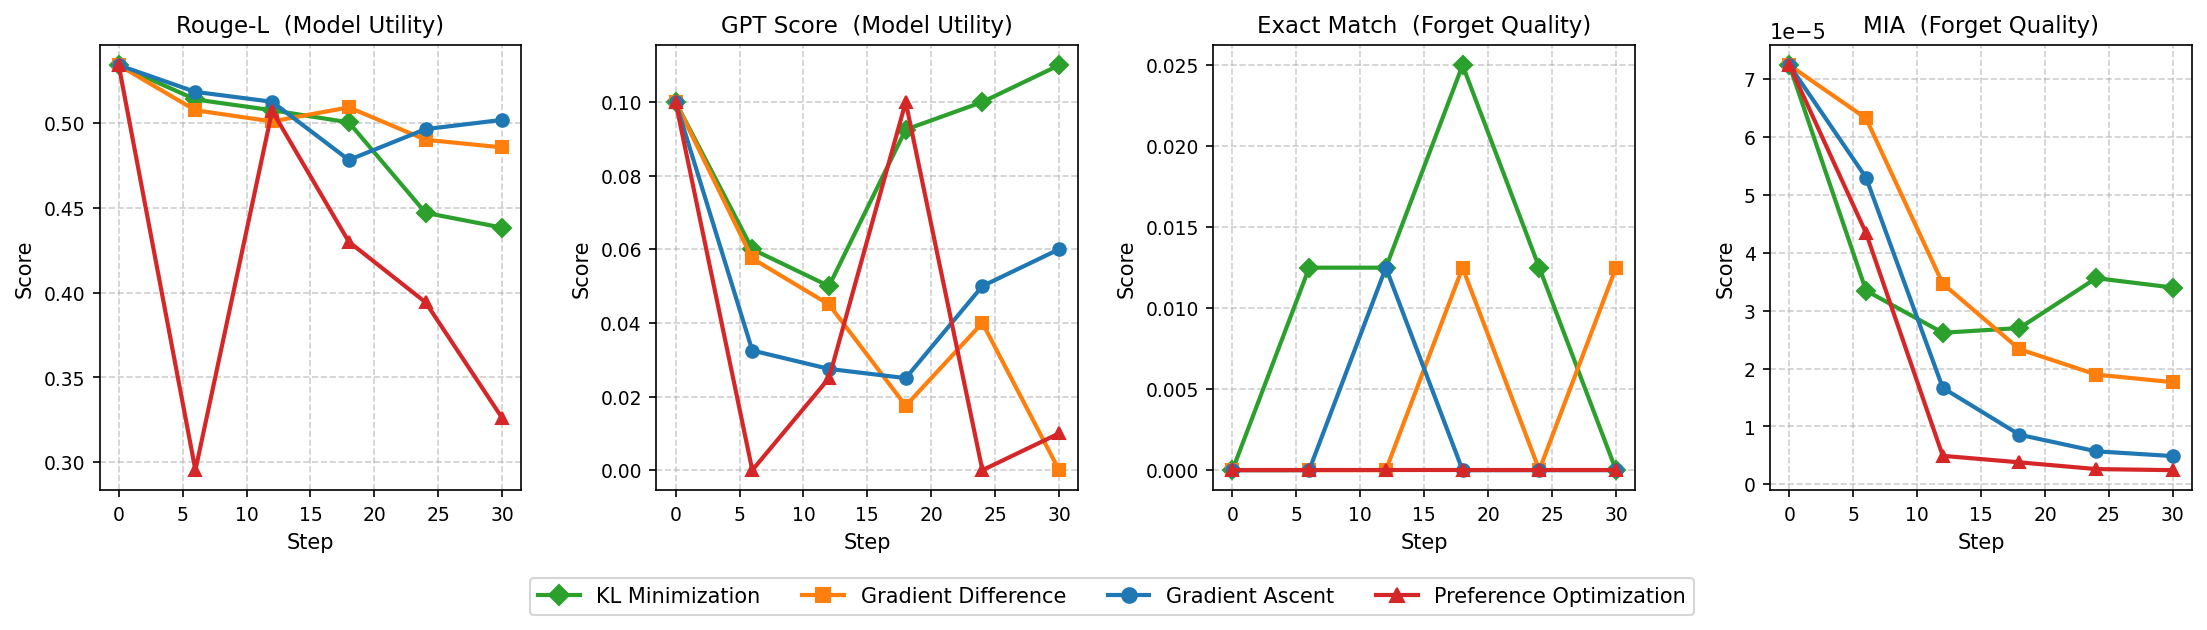

In [15]:
import subprocess

PROJECT_ROOT    = '/content/FIUBench_Reproducing'
DRIVE_STEP_EVAL = '/content/drive/MyDrive/fiubench_checkpoints/step_eval'
FIGURE_OUT      = '/content/drive/MyDrive/fiubench_checkpoints/figure2.pdf'

result = subprocess.run([
    'python', f'{PROJECT_ROOT}/scripts/plot_figure2.py',
    '--eval_dir', DRIVE_STEP_EVAL,
    '--out',      FIGURE_OUT,
], capture_output=True, text=True)

print(result.stdout)
if result.stderr:
    print('STDERR:', result.stderr[-500:])

# Show inline in Colab
from IPython.display import Image as IPImage, display
import glob
pngs = glob.glob(FIGURE_OUT.replace('.pdf', '.png'))
if pngs:
    display(IPImage(pngs[0]))


## Figure 1 — Model Utility vs Forget Quality Scatter

Final-step data loaded:
  ga      step= 30  MU=0.281  FQ(MIA)=0.000
  gd      step= 30  MU=0.243  FQ(MIA)=0.000
  kl      step= 30  MU=0.274  FQ(MIA)=0.000
  po      step= 30  MU=0.168  FQ(MIA)=0.000
  retain        MU=0.169  FQ(MIA)=0.537

✅ Saved → /content/drive/MyDrive/fiubench_checkpoints/figure1_scatter.pdf


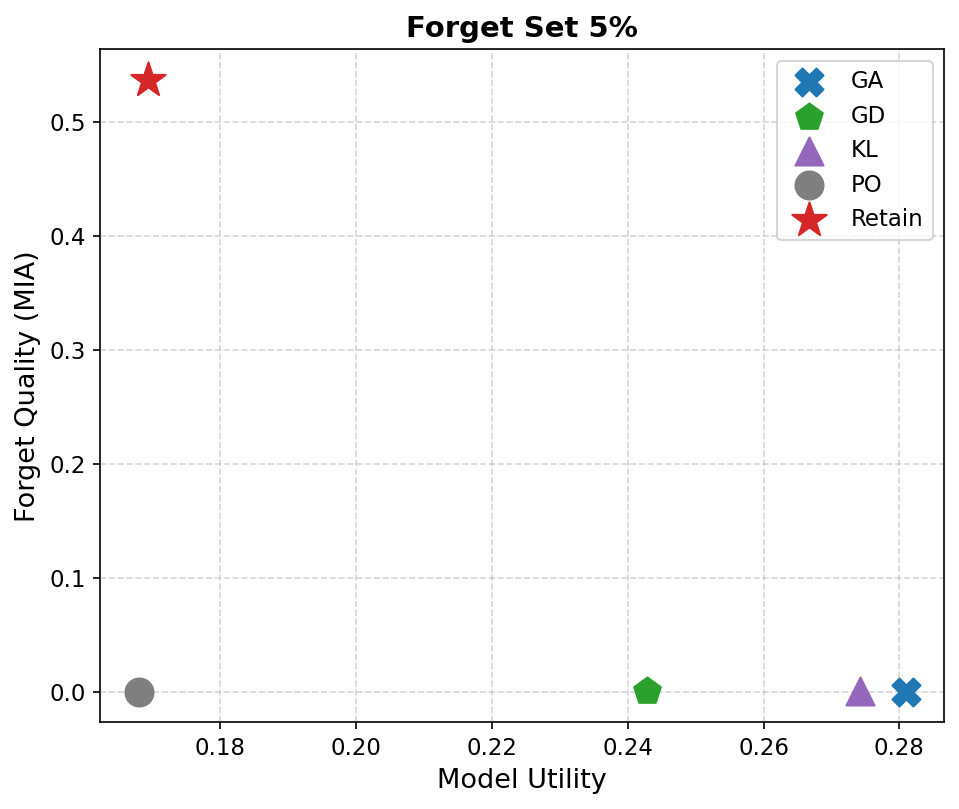

In [16]:
import json, glob
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

DRIVE_STEP_EVAL = '/content/drive/MyDrive/fiubench_checkpoints/step_eval'
FIGURE_OUT      = '/content/drive/MyDrive/fiubench_checkpoints/figure1_scatter.pdf'

# ── Load all step_eval JSONs → keep only the final step per method ───────────
method_data = {}
for p in sorted(Path(DRIVE_STEP_EVAL).glob('*.json')):
    try:
        d = json.loads(p.read_text())
        m, s = d['method'], int(d['step'])
        if m not in method_data or s > method_data[m]['step']:
            method_data[m] = d
    except Exception:
        pass

# Retain: read retain_step0000.json if it exists, else use eval_accurate output
retain_path = Path(DRIVE_STEP_EVAL) / 'retain_step0000.json'
if retain_path.exists():
    retain_d = json.loads(retain_path.read_text())
    retain_mu = (retain_d.get('rouge_l', 0) + retain_d.get('gpt_eval', 0)) / 2
    retain_fq = retain_d.get('mia_mink', 0)
else:
    # Hardcode from eval_accurate.py output above (avg_mu / 100, avg_fq / 100)
    retain_mu = 0.1694
    retain_fq = 0.5368

print("Final-step data loaded:")
for m, d in method_data.items():
    mu = (d.get('rouge_l', 0) + d.get('gpt_eval', 0)) / 2
    fq = d.get('mia_mink', 0)
    print(f"  {m:6s}  step={d['step']:3d}  MU={mu:.3f}  FQ(MIA)={fq:.3f}")
print(f"  retain        MU={retain_mu:.3f}  FQ(MIA)={retain_fq:.3f}")

# ── Style ─────────────────────────────────────────────────────────────────────
STYLE = {
    'ga':     dict(label='GA',     color='#1f77b4', marker='X',  s=180),
    'gd':     dict(label='GD',     color='#2ca02c', marker='p',  s=180),
    'kl':     dict(label='KL',     color='#9467bd', marker='^',  s=180),
    'po':     dict(label='PO',     color='#7f7f7f', marker='o',  s=180),
    'retain': dict(label='Retain', color='#d62728', marker='*',  s=300),
}

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6.5, 5.5))

for method, d in method_data.items():
    if method not in STYLE:
        continue
    mu = (d.get('rouge_l', 0) + d.get('gpt_eval', 0)) / 2
    fq = d.get('mia_mink', 0)
    st = STYLE[method]
    ax.scatter(mu, fq, color=st['color'], marker=st['marker'],
               s=st['s'], label=st['label'], zorder=3)

# Retain point
ax.scatter(retain_mu, retain_fq,
           color=STYLE['retain']['color'], marker=STYLE['retain']['marker'],
           s=STYLE['retain']['s'], label=STYLE['retain']['label'], zorder=3)

ax.set_xlabel('Model Utility', fontsize=13)
ax.set_ylabel('Forget Quality (MIA)', fontsize=13)
ax.set_title('Forget Set 5%', fontsize=14, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=11, frameon=True, loc='best')
ax.tick_params(labelsize=11)

fig.tight_layout()
Path(FIGURE_OUT).parent.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURE_OUT, dpi=150, bbox_inches='tight')
png_out = FIGURE_OUT.replace('.pdf', '.png')
fig.savefig(png_out, dpi=150, bbox_inches='tight')
print(f"\n✅ Saved → {FIGURE_OUT}")

from IPython.display import Image as IPImage, display
display(IPImage(png_out))
plt.close()
